# Requirement 4 — Slightly Non-Stationary Environment, Multiple Campaigns

The environment is `AdversarialMultiCampaignEnv(mode='shocks')`: the same class as Requirement 3, parameterised for **piecewise-stationary** dynamics with 5 blocks of length 2000. All problem parameters (N=4, T=10000, B=1600, rho=0.16, conflict edges `(0,1)` and `(2,3)`) are shared with Requirements 2 and 3.

**Three agents compared:**

1. **Sliding-Window Combinatorial-UCB** (`SlidingWindowCombinatorialUCBAgent`, `W=500` in the final main configuration): forgets old samples through a rolling window.
2. **CUSUM Combinatorial-UCB** (`CUSUMCombinatorialUCBAgent`, `h=8`, `eps=0.02`): detects changes per `(campaign, bid)` cell using CUSUM on the win indicator, resetting statistics on detection.
3. **Primal-Dual** (`PrimalDualMultiCampaignAgent`, Requirement 3): reused without a structural catch-up rule, but retuned for Requirement 4 with `budget_pacing=True`, `hedge_eta=0.16`, and `ogd_eta=0.003`.

**Three benchmarks (reported together):**

| Tier | Oracle | What it knows |
|------|--------|---------------|
| **Primary** | Piecewise expected clairvoyant | Block boundaries + true per-block distributions; not individual $m_t$ |
| Secondary | OPT$^A$ | Best fixed distribution in hindsight (same methodology as Requirement 3) |
| Reference | Dynamic / prophet | Every realised $m_t$; useful as an upper-bound reference, not the primary score |

The primary benchmark is the natural target for a piecewise-stationary setting. The dynamic oracle is reported for completeness only; its informational advantage over the learner cannot be closed by tuning alone.


In [1]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

DATA_DIR    = ROOT / "data" / "picklefiles"
OUTPUTS_DIR = ROOT / "outputs"

def load_pickle(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the experiment cell first.")
    with path.open("rb") as f:
        return pickle.load(f)

def show_png(relative_path, width=900):
    path = OUTPUTS_DIR / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Missing plot:* `{path}` — run the experiment cell first."))

2026-07-10 12:18:41,824 | ============================================================


2026-07-10 12:18:41,824 | Requirement 4 - Slightly Non-Stationary, Multiple Campaigns


2026-07-10 12:18:41,825 | ============================================================


2026-07-10 12:18:41,825 | Parameters | N=4 T=10000 B=1600.0 rho=0.1600 n_intervals=5 block_size=2000 sw_window=500 U_T=4 pd_hedge_eta=0.1600 pd_ogd_eta=0.0030 budget_pacing=True trials=20


2026-07-10 12:18:41,827 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=shocks conflict_edges=[(0, 1), (2, 3)]


...

2026-07-10 12:28:58,328 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=shocks conflict_edges=[(0, 1), (2, 3)]


2026-07-10 12:28:58,329 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 9, 10, 10] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.16000 ogd_eta=0.00300 budget_pacing=True edges=[(0, 1), (2, 3)]


2026-07-10 12:28:58,339 | Piecewise expected clairvoyant | T=10000 blocks=5 total_utility=6415.464 per_round=0.6415


2026-07-10 12:28:58,942 | Saved results to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\data\picklefiles\req4_primal_dual_results.pkl


2026-07-10 12:28:59,241 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_regret_piecewise.png


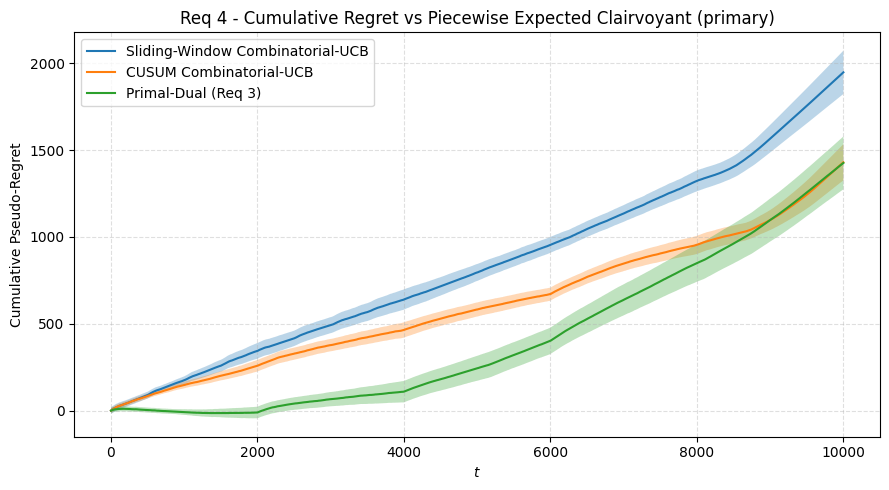

2026-07-10 12:28:59,532 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_regret_opta.png


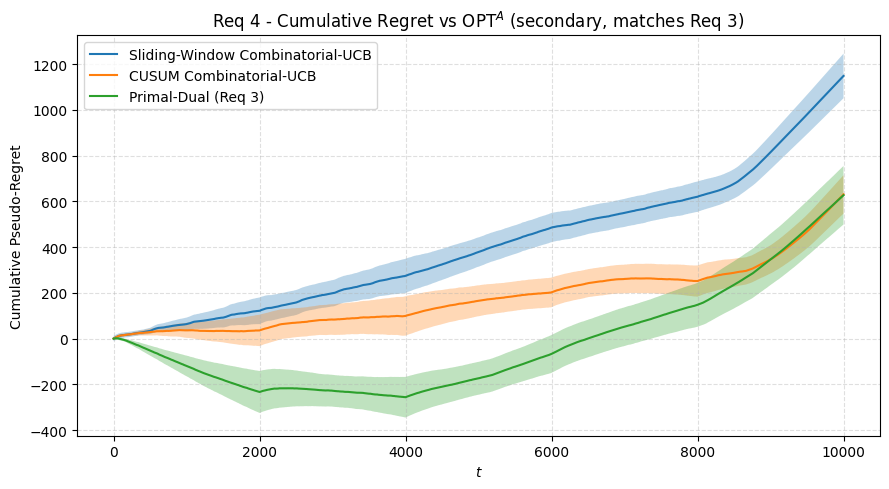

2026-07-10 12:28:59,820 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_regret_prophet.png


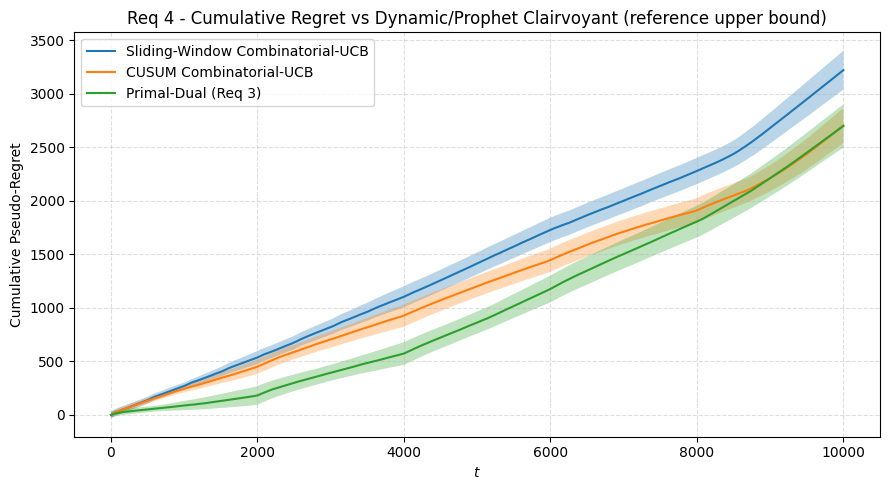

2026-07-10 12:29:00,102 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_budget.png


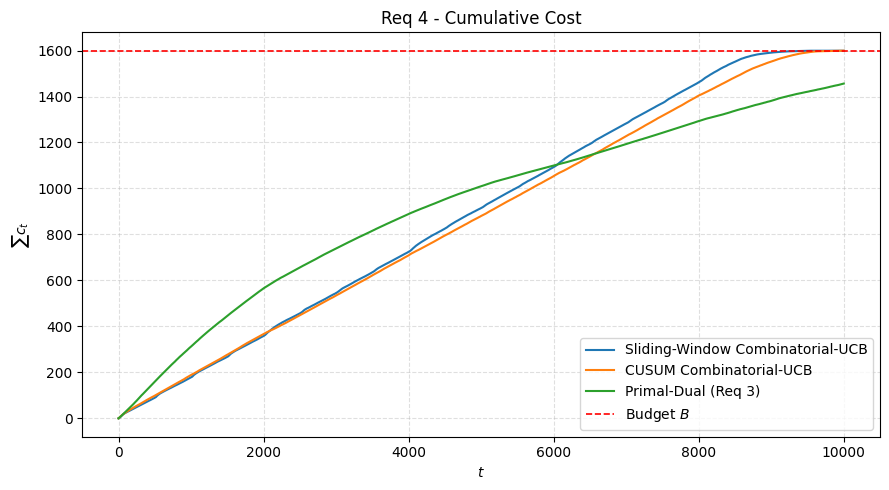

2026-07-10 12:29:00,390 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_cusum_resets.png


2026-07-10 12:29:00,542 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_lambda.png


2026-07-10 12:29:00,542 | ============================================================


2026-07-10 12:29:00,543 | Final regret (mean over 20 trials):


2026-07-10 12:29:00,543 |                           piecewise      OPT^A    prophet


...

2026-07-10 12:29:00,545 |   CUSUM Combinatorial-UCB 1599.28 / 1600


2026-07-10 12:29:00,546 |   Primal-Dual (Req 3)    1456.37 / 1600


2026-07-10 12:29:00,546 | ============================================================


2026-07-10 12:29:00,547 | Requirement 4 complete.


{'sw': {'mean_regret': array([5.44820417e-01, 1.08964083e+00, 1.48446125e+00, ...,
         3.22013453e+03, 3.22067935e+03, 3.22122417e+03], shape=(10000,)),
  'std_regret': array([1.62182269e-01, 3.24364539e-01, 5.04178412e-01, ...,
         8.11178013e+02, 8.11338222e+02, 8.11498431e+02], shape=(10000,)),
  'mean_cumcost': array([0.00000e+00, 0.00000e+00, 2.00000e-02, ..., 1.59922e+03,
         1.59922e+03, 1.59922e+03], shape=(10000,)),
  'n_trials': 20,
  'mean_regret_piecewise': array([4.48733359e-01, 8.97466718e-01, 1.19620008e+00, ...,
         1.94685957e+03, 1.94724564e+03, 1.94763170e+03], shape=(10000,)),
  'std_regret_piecewise': array([2.58048696e-01, 5.16097391e-01, 7.00985393e-01, ...,
         5.56530518e+02, 5.56745399e+02, 5.56960305e+02], shape=(10000,)),
  'mean_regret_opt_a': array([3.37526370e-01, 6.75052740e-01, 8.62579110e-01, ...,
         1.14760865e+03, 1.14794617e+03, 1.14828370e+03], shape=(10000,)),
  'std_regret_opt_a': array([1.18649433e-01, 2.37298867e-

In [2]:
from utils.run_req4 import run_req4
_QUICK_CHECK = False  # set to False for the full 20-trial run
run_req4(n_trials=5 if _QUICK_CHECK else None)

In [3]:
try:
    res_sw    = load_pickle("req4_sw_cucb_results.pkl")
    res_cusum = load_pickle("req4_cusum_cucb_results.pkl")
    res_pd    = load_pickle("req4_primal_dual_results.pkl")
except FileNotFoundError as _e:
    display(Markdown(f"**Run the `run_req4()` cell above first, then re-run this cell.**\n\n`{_e}`"))
    raise

agents = [
    ("CUSUM Combinatorial-UCB",          res_cusum),
    ("Sliding-Window Combinatorial-UCB", res_sw),
    ("Primal-Dual (Req 3)",              res_pd),
]

def _fmt(res, key):
    arr = res.get(key)
    return f"{arr[-1]:.1f}" if arr is not None else "—"

rows = ["| Agent | Piecewise (primary) | OPT^A (secondary) | Prophet (reference) | Cost / B |",
        "| --- | --- | --- | --- | --- |"]
for label, res in agents:
    pw   = _fmt(res, "mean_regret_piecewise")
    oa   = _fmt(res, "mean_regret_opt_a")
    prph = f"{res['mean_regret'][-1]:.1f}"
    cost = f"{res['mean_cumcost'][-1]:.1f} / 1600"
    rows.append(f"| {label} | {pw} | {oa} | {prph} | {cost} |")
display(Markdown("\n".join(rows)))

| Agent | Piecewise (primary) | OPT^A (secondary) | Prophet (reference) | Cost / B |
| --- | --- | --- | --- | --- |
| CUSUM Combinatorial-UCB | 1430.0 | 630.7 | 2703.6 | 1599.3 / 1600 |
| Sliding-Window Combinatorial-UCB | 1947.6 | 1148.3 | 3221.2 | 1599.2 / 1600 |
| Primal-Dual (Req 3) | 1426.1 | 626.8 | 2699.7 | 1456.4 / 1600 |

## Primal-Dual comparison with Requirement 3 learning rates

The final Requirement 4 run uses `hedge_eta=0.16` and `ogd_eta=0.003`, tuned for the shocks environment. For comparison, we also run only the Primal-Dual agent with the Requirement 3 configuration: default Hedge rate `sqrt(log(K)/T)` and `ogd_eta=0.017`. This run is saved separately and does not overwrite the main Requirement 4 results.


In [4]:
from utils.run_req4_pd_req3_eta import run_req4_pd_req3_eta

_RUN_REQ3_ETA_COMPARISON = False  # results are already saved; set True to rerun
if _RUN_REQ3_ETA_COMPARISON:
    run_req4_pd_req3_eta()


| Primal-Dual setting | Piecewise (primary) | OPT^A | Prophet | Cost / B | Final lambda |
| --- | --- | --- | --- | --- | --- |
| Req4 tuned (`hedge_eta=0.16`, `ogd_eta=0.003`) | 1426.1 | 626.8 | 2699.7 | 1456.4 / 1600 | 1.018 |
| Req3 eta (`default hedge`, `ogd_eta=0.017`) | 1777.4 | 978.0 | 3051.0 | 1193.9 / 1600 | 0.575 |

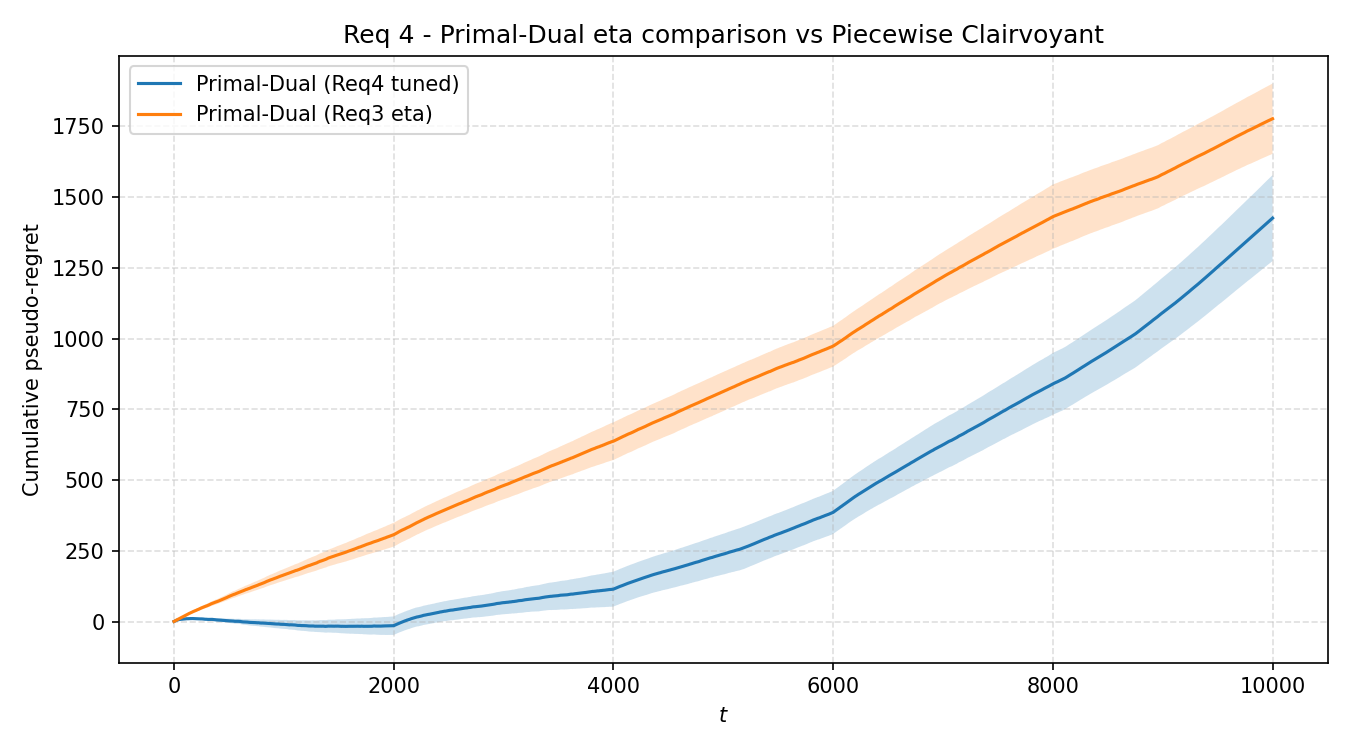

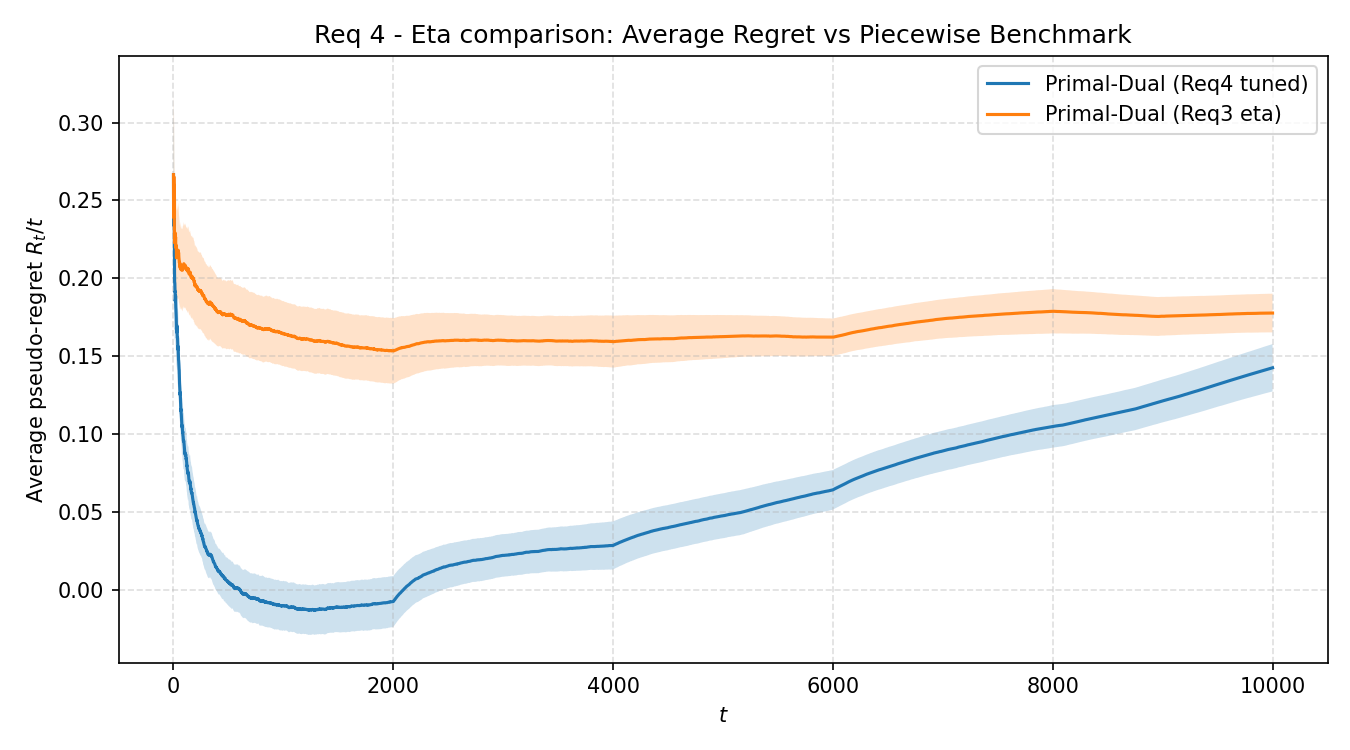

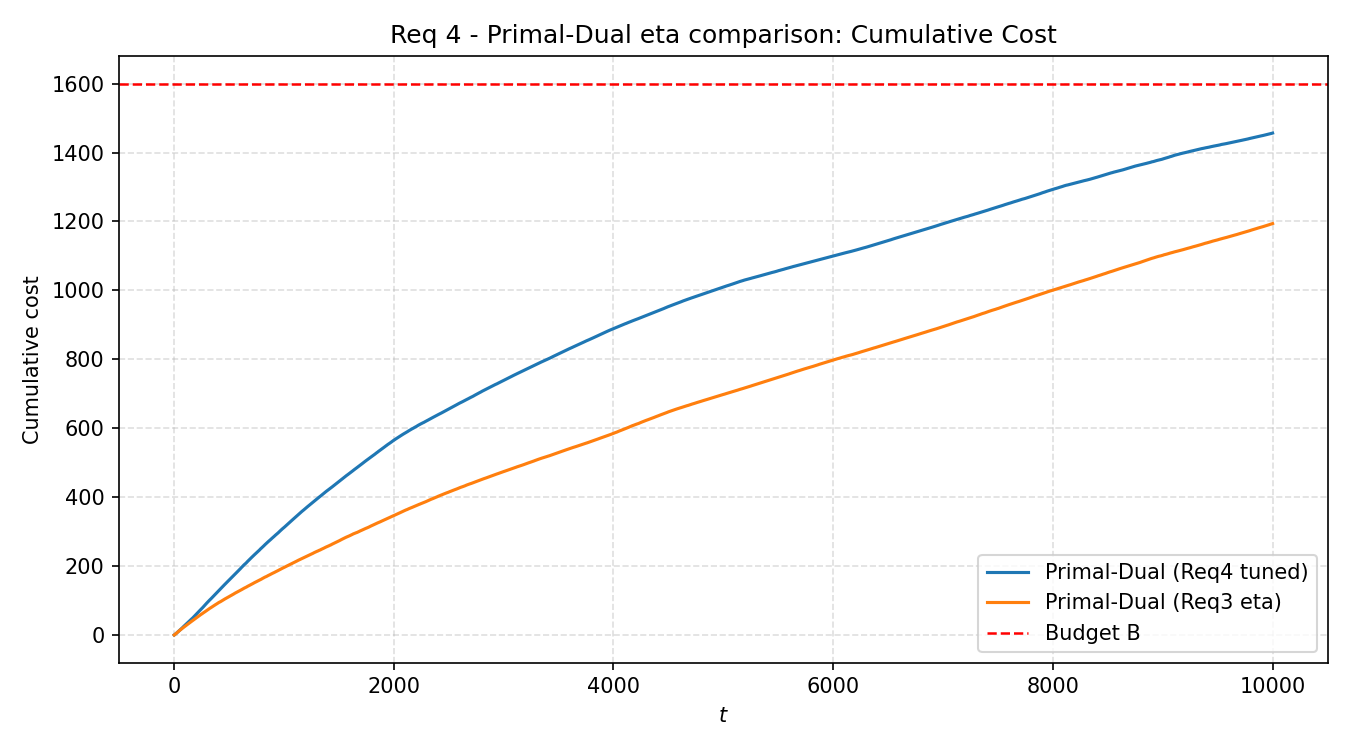

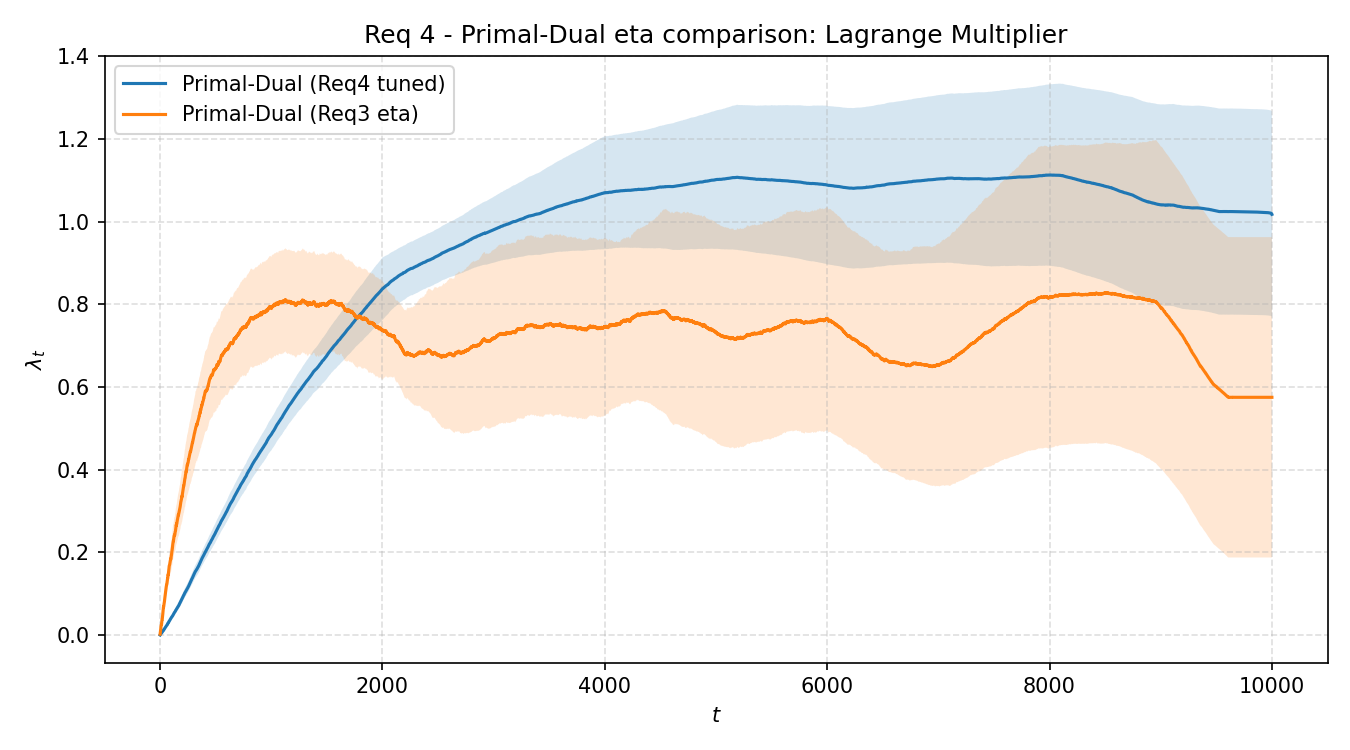

In [5]:
res_pd_req3_eta = load_pickle("req4_primal_dual_req3_eta_results.pkl")

rows = ["| Primal-Dual setting | Piecewise (primary) | OPT^A | Prophet | Cost / B | Final lambda |",
        "| --- | --- | --- | --- | --- | --- |"]
for label, res in [
    ("Req4 tuned (`hedge_eta=0.16`, `ogd_eta=0.003`)", res_pd),
    ("Req3 eta (`default hedge`, `ogd_eta=0.017`)", res_pd_req3_eta),
]:
    rows.append(
        f"| {label} | {res['mean_regret_piecewise'][-1]:.1f} | "
        f"{res['mean_regret_opt_a'][-1]:.1f} | {res['mean_regret'][-1]:.1f} | "
        f"{res['mean_cumcost'][-1]:.1f} / 1600 | {res['mean_lmbd'][-1]:.3f} |"
    )
display(Markdown("\n".join(rows)))

for path in [
    "r4/req3_eta_comparison/comparison_regret_piecewise.png",
    "r4/req3_eta_comparison/comparison_average_regret_piecewise.png",
    "r4/req3_eta_comparison/comparison_budget.png",
    "r4/req3_eta_comparison/comparison_lambda.png",
]:
    show_png(path)


## Regret and Average Regret

Regret is measured against the primary benchmark (piecewise expected clairvoyant). With the final `origin/main` code and the Req4-tuned Primal-Dual rates, CUSUM and Primal-Dual are essentially tied, while Sliding-Window is worse under the final `W=500` configuration.


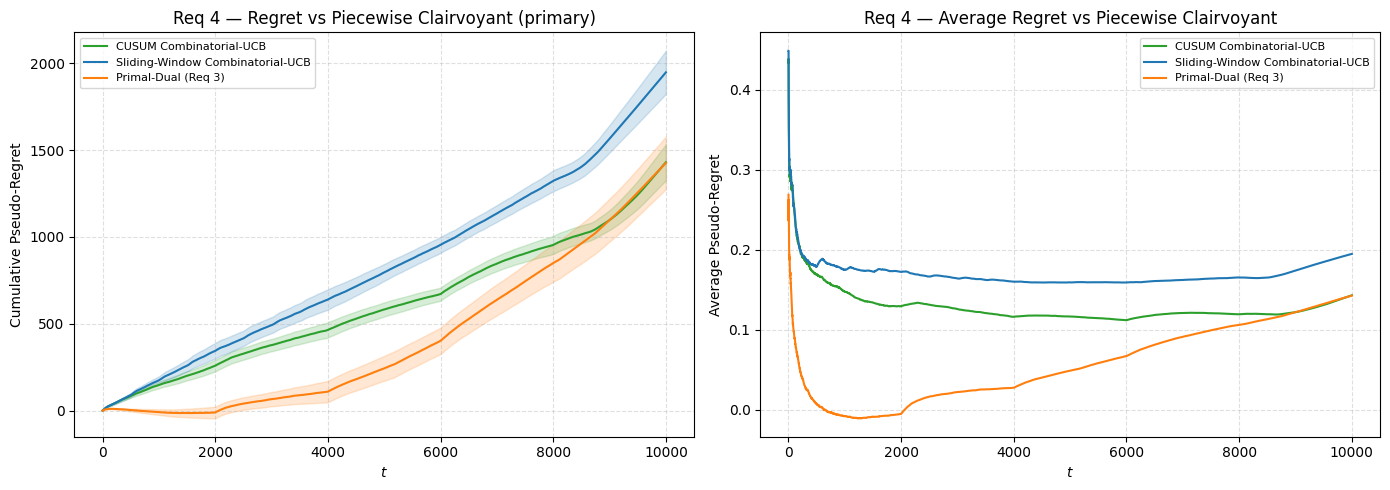

In [6]:
T_run = len(res_sw["mean_regret"])
ts    = np.arange(1, T_run + 1)
colors = {"CUSUM Combinatorial-UCB": "C2",
          "Sliding-Window Combinatorial-UCB": "C0",
          "Primal-Dual (Req 3)": "C1"}

def _piecewise_mean(res):
    return np.array(res.get("mean_regret_piecewise", res["mean_regret"]))

def _piecewise_std(res):
    return np.array(res.get("std_regret_piecewise", res["std_regret"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, res in agents:
    mean   = _piecewise_mean(res)
    stderr = _piecewise_std(res) / np.sqrt(res["n_trials"])
    ax.plot(ts, mean, label=label, color=colors[label])
    ax.fill_between(ts, mean - stderr, mean + stderr, alpha=0.18, color=colors[label])
ax.set_xlabel("$t$"); ax.set_ylabel("Cumulative Pseudo-Regret")
ax.set_title("Req 4 — Regret vs Piecewise Clairvoyant (primary)")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
for label, res in agents:
    mean = _piecewise_mean(res)
    ax.plot(ts, mean / ts, label=label, color=colors[label])
ax.set_xlabel("$t$"); ax.set_ylabel("Average Pseudo-Regret")
ax.set_title("Req 4 — Average Regret vs Piecewise Clairvoyant")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()

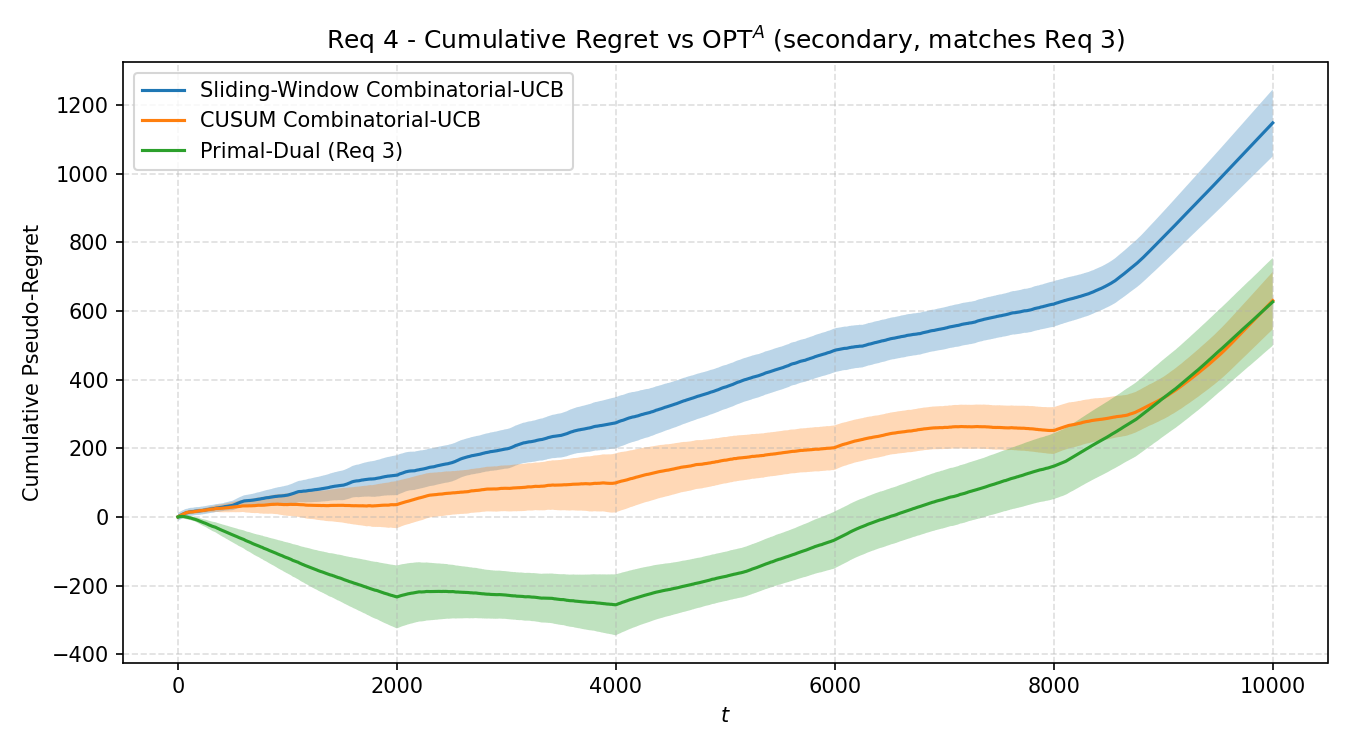

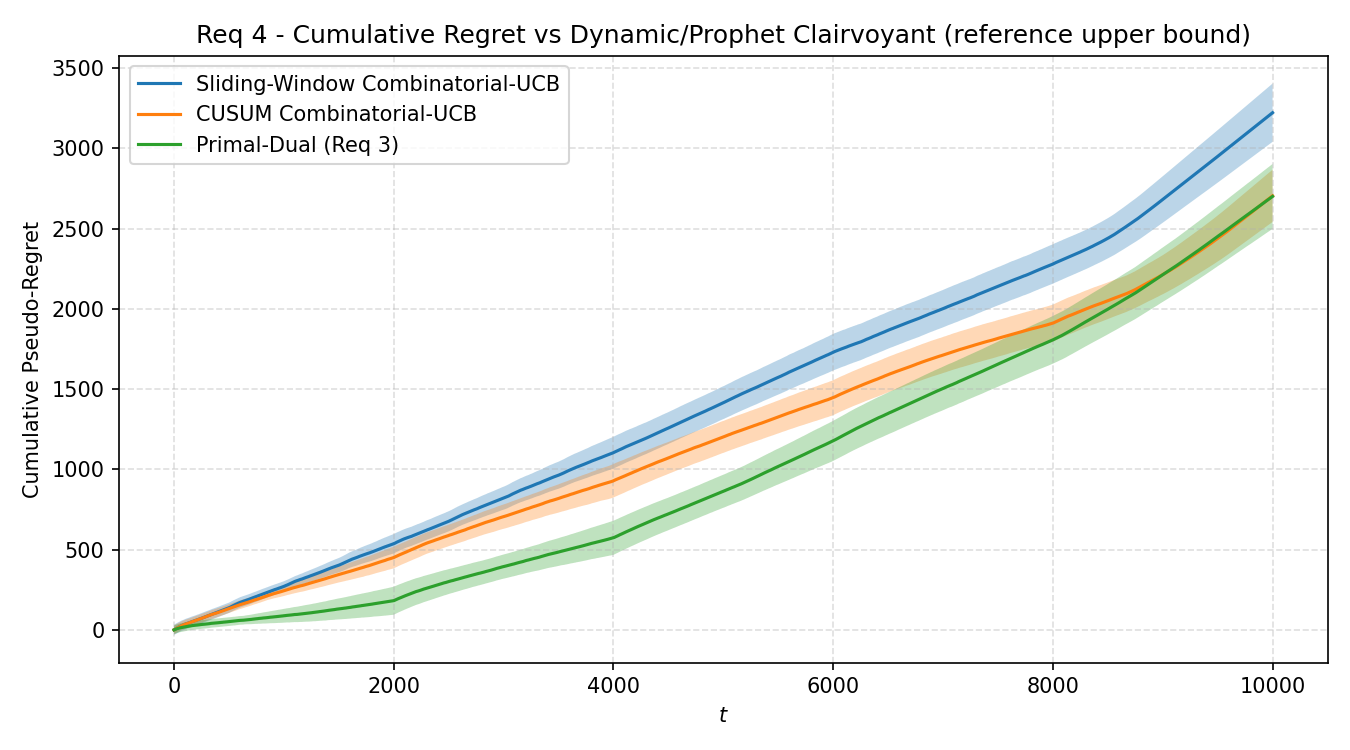

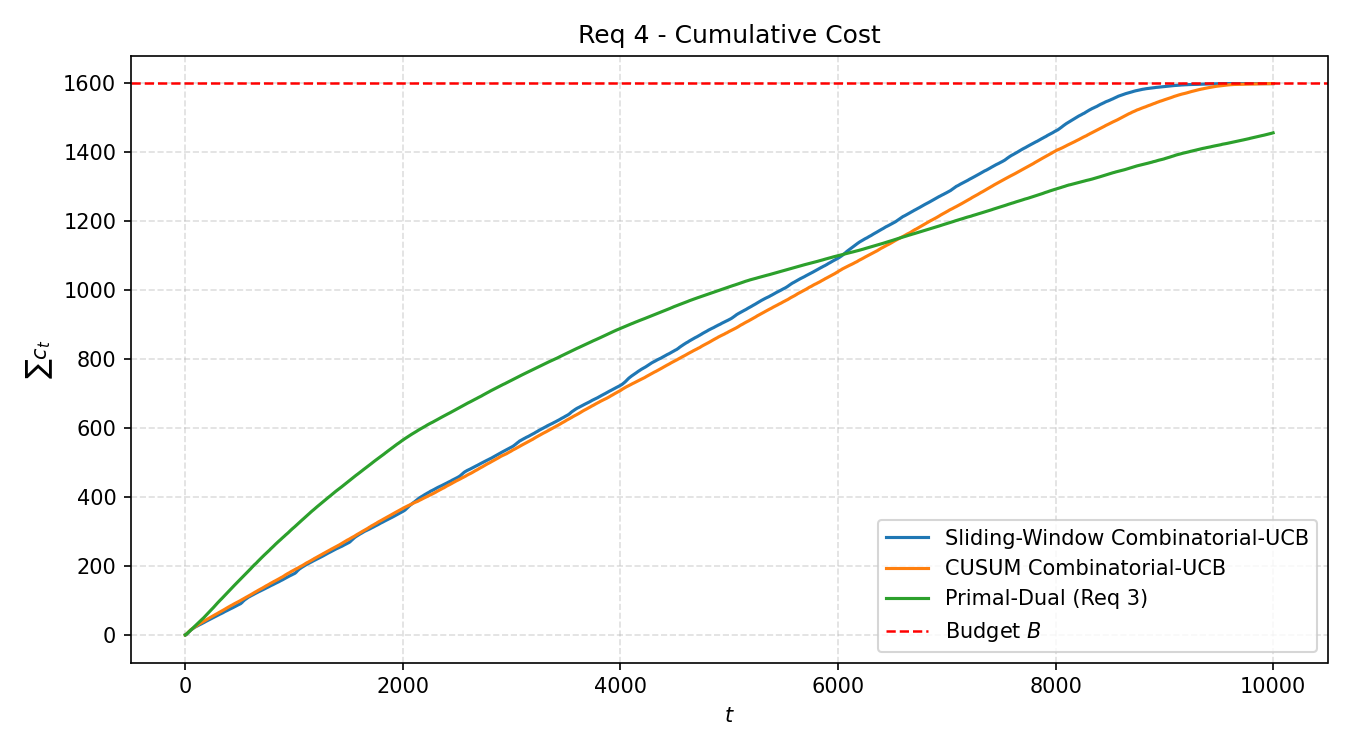

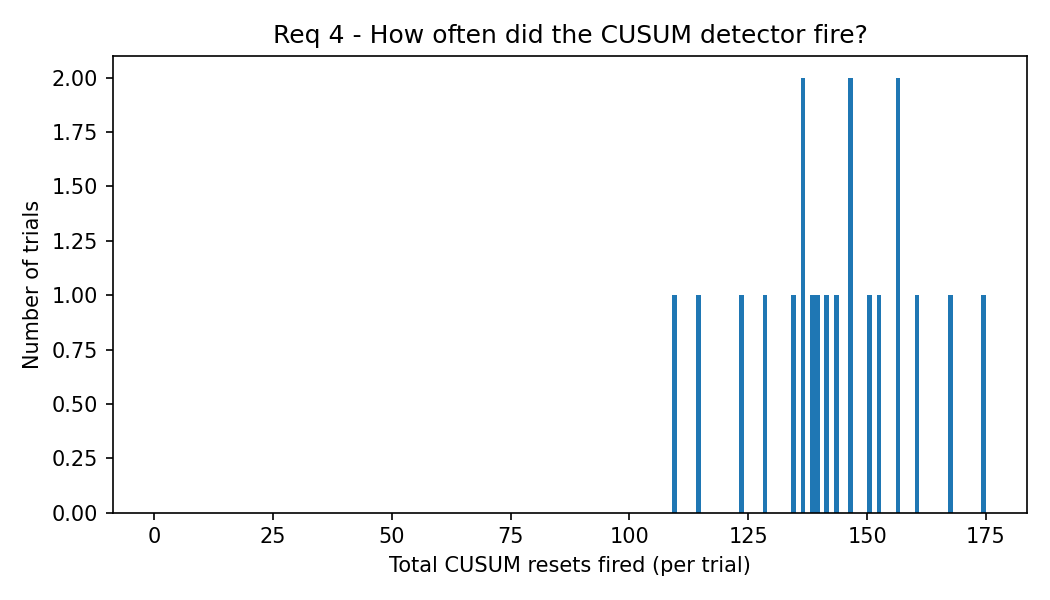

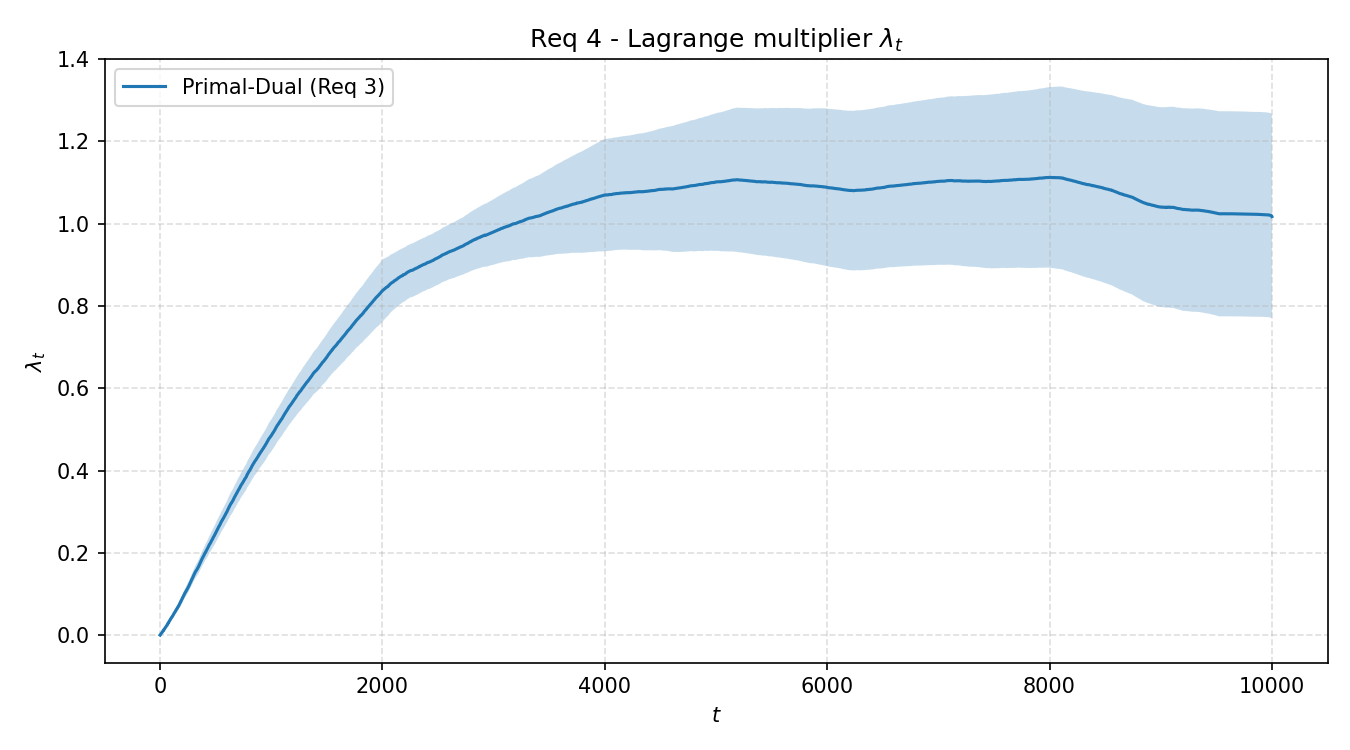

In [7]:
for path in [
    "r4/req4_regret_opta.png",
    "r4/req4_regret_prophet.png",
    "r4/req4_budget.png",
    "r4/req4_cusum_resets.png",
    "r4/req4_lambda.png",
]:
    show_png(path)

## Interpretation

- **Final ranking on the primary benchmark:** Primal-Dual (1426.10) and CUSUM (1429.43) are essentially tied, with Primal-Dual slightly lower in this 20-trial run. Sliding-Window is worse (1950.41), likely because the final main configuration uses `W=500`, shorter than a full 2000-round regime.
- **Benchmark scale still matters.** Regret against the prophet is much larger than regret against the piecewise expected clairvoyant because the prophet knows every realised competing bid. This is an information advantage, not a realistic learning target.
- **CUSUM remains theoretically natural** for piecewise stationarity because it explicitly detects changes. In this run it fires often (mean 145.3 resets across 38 cells), which helps adaptation but also introduces extra resets/noise.
- **Primal-Dual tuning.** The Req3-style default was too conservative for Requirement 4. Increasing the primal Hedge rate and lowering the dual OGD rate (`hedge_eta=0.16`, `ogd_eta=0.003`) improved regret and raised budget use to 1456.37/1600.
- **Budget under-use is not fully removable by eta tuning.** The Primal-Dual algorithm enforces an upper budget constraint; it is not designed to spend every leftover unit. Making it spend almost exactly 1600 would require a catch-up or terminal-pacing objective, which would be a different algorithmic variant rather than a pure retuning of Requirement 3's Primal-Dual method.
- **Lambda plot interpretation.** A positive, moving $\lambda_t$ is expected in this non-stationary setting: it is the learned shadow price of budget. The plot explains why Primal-Dual remains feasible and somewhat conservative, but it should not be read as a promise of exact budget exhaustion.
- **Req3-eta comparison.** Running Primal-Dual in the Req4 shocks environment with the Requirement 3 rates (`hedge_eta≈0.015`, `ogd_eta=0.017`) is more conservative: it spends 1193.92/1600 and has higher piecewise regret (1777.40) than the Req4-tuned version (1426.10). This justifies keeping Req4-specific rates without changing the main results.
